In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
df = pd.read_csv("../data/preprocessed_data.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,Class,hour,hour_sin,hour_cos,Amount_categorical_large,Amount_categorical_medium,Amount_categorical_small,Amount_categorical_very_large,Amount_categorical_zero_amount,Amount_log
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,5.014760
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.305626
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,5.939276
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,4.824306
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,4.262539


In [4]:
X = df.drop(["Class", "hour", "Amount"], axis=1)
y = df["Class"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11, stratify=y)

In [6]:
# smote_tomek = SMOTETomek(random_state=20)
# X_st, y_st = smote_tomek.fit_resample(X_train, y_train)

In [7]:
# X_st = pd.read_csv("../data/X_train_smote_tomek.csv")
# y_st = pd.read_csv("../data/y_train_smote_tomek.csv")

In [8]:
# # Fix shape
# y_st = y_st.values.ravel()
#
# y_st = pd.Series(y_st, name="Class")
#
# # Save
# X_st.to_csv("../data/X_train_smote_tomek.csv", index=False)
# y_st.to_csv("../data/y_train_smote_tomek.csv", index=False)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [10]:
# print(X_train_scaled.shape)
# print(X_test_scaled.shape)
# print(X_train_scaled.dtype)

C:\Work\FraudDetection\FraudDetection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


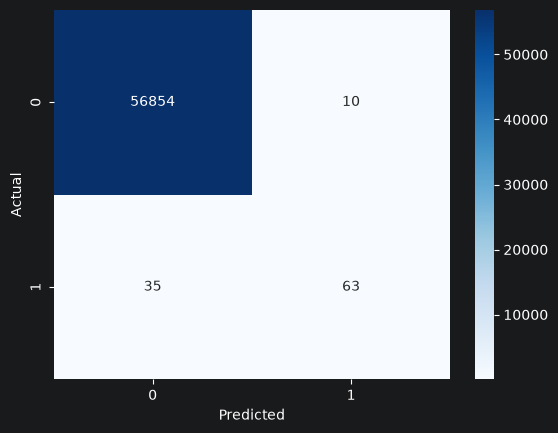

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.64      0.74        98

    accuracy                           1.00     56962
   macro avg       0.93      0.82      0.87     56962
weighted avg       1.00      1.00      1.00     56962



In [11]:
logreg = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=100,
    random_state=42
)

logreg.fit(X_train_scaled, y_train)

y_pred = logreg.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print(classification_report(y_test, y_pred))